In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np
import geopandas as gpd
# import tesspy
import shapely
import matplotlib.dates as mdates

import random
import dill
from pathlib import Path
import os


from fame import *
from fame_msa_utils import ShipTracker, ship_propagator, custom_ship_phenomenon_processor, propagate_distribution_from_observations

import h3


In [2]:
R_earth_km = 6371


## Load satellites

In [3]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
# tle_file_name_txt = "tles/all_tles_20260130.txt"
tle_file_name_txt = "tles/all_tles_20260427.txt"

# min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
# max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

lookahead_horizon_h = 36


min_time = dt.datetime.strptime("2026-04-27 00:00:00.00000", "%Y-%m-%d %H:%M:%S.%f").replace(tzinfo=None)
max_time=min_time + dt.timedelta(seconds=3600*lookahead_horizon_h)


In [6]:
flock_names = []

iceye_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            
with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("ICEYE"):
            # .strip() removes the trailing newline character (\n)
            iceye_names.append(line.strip()) 


In [7]:
print(f"There are {len(flock_names)} Flock sats and {len(iceye_names)} ICEYE sats")

There are 129 Flock sats and 52 ICEYE sats


In [8]:
# planet_satellites = []
# 14-19 decayed

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Ubotica ACCENTURE-1 SUAC": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}
for dove_name in flock_names:
    swaths_at_nadir_km[dove_name] =  16.4 #https://www.newspace.im/constellations/planet-labs

for iceye_name in iceye_names:
    swaths_at_nadir_km[iceye_name] =  100 # Scan imaging, https://sar.iceye.com/5.2.3/productguide/typesofsarcollection/

# print("HACK!")
# for sat, swath in swaths_at_nadir_km.items():
#     if swath<20:
#         swaths_at_nadir_km[sat]*=10

# dove_satellites = [
#     Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
#     for dove_name in flock_names
#     ]

dove_satellites = []

iceye_satellites = [
    Satellite(iceye_name, Orbital(iceye_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True)
    for iceye_name in iceye_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
try:
    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:

    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

try:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
ubotica_satellites = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("Ubotica ACCENTURE-1 SUAC", Orbital("ACCENTURE-1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [9]:
all_satellites = dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+iceye_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [10]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {it: _fov for it in _sat.instruments}

In [11]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "FLOCK" in sat_name.upper():
        return "midnightblue"
    if "SKYSAT" in sat_name.upper():
        return "midnightblue"
    if "PELICAN" in sat_name.upper():
        return "mediumblue"
    if "TANAGER" in sat_name.upper():
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name.upper():
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "darkorange"
    # 
    if "LOFT" in sat_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "orchid"
    #
    if "ICEYE" in sat_name.upper():
        return "darkturquoise"
    #
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name.upper():
        return "blue"
    # Black
    if "UMBRA" in constellation_name.upper():
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name.upper():
        return "darkorange"
    # 
    if "LOFT" in constellation_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in constellation_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in constellation_name.upper():
        return "orchid"
    if "ICEYE" in constellation_name.upper():
        return "darkturquoise"
    return "red"

def satmarkerer(sat_name):
    if "FLOCK" in sat_name.upper():
        return "p"
    if "SKYSAT" in sat_name.upper():
        return "p"
    if "PELICAN" in sat_name.upper():
        return "p"
    if "TANAGER" in sat_name.upper():
        return "p"
    # Black
    if "UMBRA" in sat_name.upper():
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "D"
    # 
    if "LOFT" in sat_name.upper():
        return "p"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "p"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "p"
    #
    if "ICEYE" in sat_name.upper():
        return "D"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}



In [12]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

Gothenburg = Location(11.14, 58.10, 0, "Gothenburg")

### Communication opportunities

In [13]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [14]:
# min_time=dt.datetime.now(dt.timezone.utc)
# max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

## Dispatching the workflow

We now have a graph with one .observation_opportunity per ConstrainedObservationRequest. When do we actually dispatch it?

Idea: when the parent constraint are satisfied (per the dispatch policy). 
We will also have to separately handle "what if we dispatch before a constraint is resolved, and it gets resolved in a way we did not expect".

So:
- Go over the list of tasks
- If a task is not Dispatched
- Check their constraints according to the mask in .dispatch_policy
- If it is dispatchable
- Dispatch it

## Define the phenomenon of interest (i.e., the ship)

In [15]:
phenomenon_update_frequency = dt.timedelta(seconds=1800)

avg_speed_kph = 37/2 # 20 kts
start_speed_kph = avg_speed_kph
start_heading_deg = 0
heading_variance = .075/5
speed_variance = 0.5

# avg_speed_kph2 = 30 # 20 kts
# start_speed_kph2 = avg_speed_kph2
start_heading_deg_G = 250
# heading_variance = .075
# speed_variance = 0.5

phenomena_rotterdam = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=min_time+phenomenon_update_frequency,
        name = Rotterdam.name,
        heading_deg=start_heading_deg,
        speed_kph=start_speed_kph
    ),
]

initial_toi_pose_rotterdam = Pose(lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, time=min_time, alt_km=Rotterdam.alt_km, heading_deg=start_heading_deg, speed_kph=start_speed_kph, name="Rotterdam initial")


max_iters_per_point = 5000

new_heading_rad = start_heading_deg*np.pi/180.

random.seed(4)

while phenomena_rotterdam[-1].end_time<max_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena_rotterdam[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena_rotterdam[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena_rotterdam[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena_rotterdam[-1].end_time
    

    phenomena_rotterdam.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena_gothenburg = [
    Phenomenon(
        lon_deg = Gothenburg.lon_deg,
        lat_deg = Gothenburg.lat_deg,
        alt_km=Gothenburg.alt_km,
        start_time=min_time,
        end_time=min_time+phenomenon_update_frequency,
        name = Gothenburg.name,
        heading_deg=start_heading_deg_G,
        speed_kph=start_speed_kph
    ),
]

initial_toi_pose_gothenburg = Pose(lon_deg=Gothenburg.lon_deg, lat_deg=Gothenburg.lat_deg, time=min_time, alt_km=Gothenburg.alt_km, heading_deg=start_heading_deg, speed_kph=start_speed_kph, name="Gothenburg initial")

new_heading_rad = start_heading_deg_G*np.pi/180.

random.seed(1)

while phenomena_gothenburg[-1].end_time<max_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena_gothenburg[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena_gothenburg[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena_gothenburg[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena_gothenburg[-1].end_time
    

    phenomena_gothenburg.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Gothenburg.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Gothenburg.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena = phenomena_rotterdam+phenomena_gothenburg

phenomena_with_stationary_toi = [p for p in phenomena]

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=max_time,
        name = Rotterdam.name+ " stationary"
    ),
)

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Gothenburg.lon_deg,
        lat_deg = Gothenburg.lat_deg,
        alt_km=Gothenburg.alt_km,
        start_time=min_time,
        end_time=max_time,
        name = Gothenburg.name+ " stationary"
    ),
)

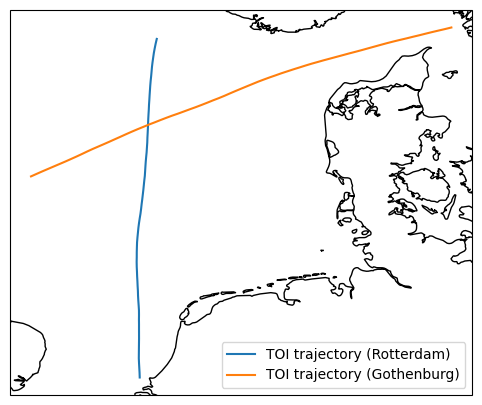

In [16]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")

axglobal.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")


axglobal.legend()


## Initialize the world, the constellations, and the brokers

In [17]:
# phenomena = []

world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

scheduler_planet = ConstellationGroundScheduler(satellites=dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")
scheduler_iceye = ConstellationGroundScheduler(satellites=iceye_satellites, ground_stations=ground_stations, world=world_with_brokers, name="ICEYE")

all_constellations = [scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace, scheduler_iceye]

constcolors = {c.name: constcolorer(c.name) for c in all_constellations}


world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)
world_with_brokers.add_constellation(scheduler_iceye)

broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 1")

other_broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 2")


world_with_brokers.add_broker(broker)
world_with_brokers.add_broker(other_broker)

world_with_brokers.time = min_time

### Create the observation requests (the geometry)

In [18]:


obs_request_initial_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=min_time+dt.timedelta(hours=3),
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

obs_request_followup_yes_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up imaging request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )



obs_request_initial_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=min_time+dt.timedelta(hours=4),
    alt_km=Gothenburg.alt_km,
    request_name="Initial RGB request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Gothenburg.alt_km,
    request_name="Follow-up search request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

obs_request_followup_yes_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Gothenburg.alt_km,
    request_name="Follow-up imaging request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

## Create the workflow!

We start with some static functions we will use to compute rewards

In [19]:
def rewarder_observation(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 50
    
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    
    zenith_angle_reward = abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90
    
    # if the Sun is below the horizon
    # if abs(opportunity.sun_zenith_angle_deg)>90 and opportunity.instrument == InstrumentType.RGB:
    #     zenith_angle_reward = -100

    range_reward = 1/(opportunity.range_km/1000)

    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def rewarder_search(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 0
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    zenith_angle_reward = 0
    range_reward = 1/(opportunity.range_km/1000)
    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def success_declarer_msa_R(data_product):
    return len(data_product)>0

def success_declarer_msa_G(data_product):
    return len(data_product)>0

We create the actual constrained requests and timelines

In [20]:
from fame_msa_utils import custom_ship_phenomenon_processor


MAX_SEARCHES_PER_INTERVAL = 10
dt_h = 3

ship_location_timeline_msa = Timeline(name="Ship loc. known?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)



constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial_msa_R,
    success_declarer=success_declarer_msa_R,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    rewarder=rewarder_observation,
)

workflow_msa_reqs = [constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,lookahead_horizon_h,dt_h)):

    num_requests_in_previous_batches = len(workflow_msa_reqs)

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_msa_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
    #     )
    for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
        )



    obs_request_followup_yes_msa_Rotterdam = ObservationRequest(
        Rotterdam.lon_deg,
        Rotterdam.lat_deg,
        min_time=min_time+dt.timedelta(seconds=3600*h_ix),
        max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
        alt_km=Rotterdam.alt_km,
        request_name="Follow-up imaging request {} in Rotterdam".format(int(h_ix/dt_h)),
        min_elevation_deg=45,
        instrument=InstrumentType.RGB
        )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up obs. {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa_Rotterdam,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=success_declarer_msa_R,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        max_num_instances=1,
        plotting_group="Follow-up obs. {}".format(int(h_ix/dt_h)),
    )

    for search_ix in range(MAX_SEARCHES_PER_INTERVAL):

        obs_request_followup_no_msa_Rotterdam = ObservationRequest(
            Rotterdam.lon_deg,
            Rotterdam.lat_deg,
            min_time=min_time+dt.timedelta(seconds=3600*h_ix),
            max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
            alt_km=Rotterdam.alt_km,
            request_name="Follow-up search request {}.{} in Rotterdam".format(int(h_ix/dt_h), search_ix),
            min_elevation_deg=45,
            instrument=InstrumentType.SAR
            )
        obs_srch_constraints = [
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
                # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
                # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
            ]
        # if len(workflow_msa_reqs)>1:
        #     obs_srch_constraints.append(
        #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        #     )
        for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
            obs_srch_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        # If the prior fails, do a search
        constrained_followup_search_later = ConstrainedObservationRequest(
            name="Follow-up search {}.{}".format(int(h_ix/dt_h), search_ix),
            observation_request=obs_request_followup_no_msa_Rotterdam,
            task_constraints = obs_srch_constraints,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            success_declarer=success_declarer_msa_R,
            timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
            timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=0.1)],
            rewarder=rewarder_search,
            max_num_instances=1,
            plotting_group="Follow-up search {}".format(int(h_ix/dt_h)),
        )

        workflow_msa_reqs.append(constrained_followup_search_later)

    workflow_msa_reqs.append(constrained_followup_observation_later)


We also create the functions that update the timelines and the tasks when new information arrives. These are invoked just before replanning


In [21]:

def timeline_updater_msa(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline],
        max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800),
        verbose=True
        ):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines

def h3_to_polygon(h3_id):
    # Get the cell boundary in (lat, lng) format
    boundary_lat_lng = h3.cell_to_boundary(h3_id)
    
    # Swap to (lng, lat) because Shapely/GeoPandas expect (x, y)
    boundary_lng_lat = [(lng, lat) for lat, lng in boundary_lat_lng]
    
    # Return as a Shapely Polygon
    return Polygon(boundary_lng_lat)


def request_updater_msa(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline]=[],
        verbose=True,
        initial_toi_pose: Pose=initial_toi_pose_rotterdam,
        search_name_str: str="",
        samples_propagation=200,
        propagate_negative_samples: bool=True,
        plot_filter_distribution: bool=False,
        plot_axis: plt.axis = None,
        save_filter_distribution: bool=False,
        save_name: str=None,
        ):
    # ShipTracker ingests measurements via update_location and propagates said locations via propagate_locations.
    # Workflow:
    # Look for the latest observation in completed requests.
    
    initial_ship_location = Pose(time=min_time, lon_deg=initial_toi_pose.lon_deg, lat_deg=initial_toi_pose.lat_deg, alt_km=initial_toi_pose.alt_km, heading_deg=initial_toi_pose.heading_deg, speed_kph=initial_toi_pose.speed_kph)

    # Order unfilled requests by min_time.
    unfilled_requests = [r for r in requests if r.completed == False and r.dispatched == False and r.feasible == True and r.observation_request.max_time>current_time]
    # print(f"Unfilled requests ({len(unfilled_requests)}): {unfilled_requests}")
    unfilled_requests_dict_by_time = {}
    for ur in unfilled_requests:
        urtime = ur.observation_request.min_time+(ur.observation_request.max_time-ur.observation_request.min_time)/2
        if urtime not in unfilled_requests_dict_by_time.keys():
            unfilled_requests_dict_by_time[urtime] = []
        unfilled_requests_dict_by_time[urtime].append(ur)

    pose_propagator=lambda _previous_pose, _deltat: ship_propagator(
        previous_pose=_previous_pose,
        deltat=_deltat,
        heading_variance=heading_variance,
        speed_variance=speed_variance,
        max_speed_if_unspecified_kph=avg_speed_kph,
        )

    hexes_by_time = propagate_distribution_from_observations(
        query_times=list(unfilled_requests_dict_by_time.keys()),
        initial_pose=initial_ship_location,
        observation_requests=requests,
        pose_propagator=pose_propagator,
        target_name=search_name_str,
        h3_resolution=5, # Res 5: 9.85 km side. Res 6: 3.72 km side
        samples_propagation=samples_propagation,
        propagate_negative_samples=propagate_negative_samples,
        verbose=verbose,
        plot_filter_distribution=plot_filter_distribution,
        )

    # def found_ship_in_data_product(data_product: list[Phenomenon], search_name: str):
    #     found_request = False
    #     for ship_location_phenomenon in data_product:
    #         # If the ship is the right one
    #         if ((len(search_name)==0) or (search_name in ship_location_phenomenon.name)):
    #             found_request = True
    #             ship_location = custom_ship_phenomenon_processor(
    #                 observation=completed_request.observation_opportunity,
    #                 spacecraft=completed_request.observation_opportunity.satellite,
    #                 phenomenon=ship_location_phenomenon
    #                 )
    #             return ship_location
    #     return False

    for unfulfilled_time in unfilled_requests_dict_by_time.keys():
        points_hex_tessellation = hexes_by_time[unfulfilled_time]
        for unfulfilled_request_ix, unfulfilled_request in enumerate(unfilled_requests_dict_by_time[unfulfilled_time]):
            if unfulfilled_request_ix>len(points_hex_tessellation)-1:
                # We have run out of hexagons. Which is good! We should remove this request and the following ones. This is a very very hacky way of doing it.
                # The proper way is to pop the request from the list AND THE GRAPH
                unfulfilled_request.scheduled = True
                unfulfilled_request.dispatched = True
                unfulfilled_request.completed = True
                unfulfilled_request.feasible = False
                unfulfilled_request.successful_execution = False
                continue
            else:
                hex_centroid = points_hex_tessellation.iloc[unfulfilled_request_ix].geometry.centroid
                _updated_request = ObservationRequest(
                    lat_deg=hex_centroid.y,
                    lon_deg=hex_centroid.x,
                    min_time=unfulfilled_request.observation_request.min_time,
                    max_time = unfulfilled_request.observation_request.max_time,
                    alt_km=unfulfilled_request.observation_request.alt_km,
                    instrument=unfulfilled_request.observation_request.instrument,
                    request_name=unfulfilled_request.observation_request.name,
                    min_elevation_deg=unfulfilled_request.observation_request.min_elevation_deg,
                )
                unfulfilled_request.observation_request = _updated_request
        # fi

    return requests



### Create the workflow proper

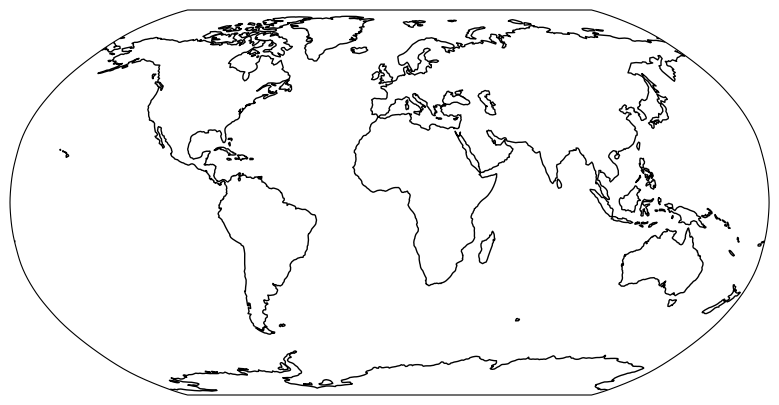

In [22]:
fig_filter_broker1 = plt.figure(figsize=(10,5))
plot_axis_broker1 = fig_filter_broker1.add_subplot(1,1,1, projection=ccrs.Robinson())
plot_axis_broker1.coastlines()

workflow_msa = Workflow(
    constrained_observation_requests=workflow_msa_reqs,
    timelines = [ship_location_timeline_msa,],
    timeline_updater=timeline_updater_msa,
    request_updater=lambda current_time, requests, timelines: request_updater_msa(
        current_time=current_time,
        requests=requests,
        timelines=timelines,
        verbose=True,
        initial_toi_pose=initial_toi_pose_rotterdam,
        search_name_str="Rotterdam",
        plot_filter_distribution=False,
        # plot_axis=plot_axis_broker1,
        save_filter_distribution=False,
        ),
)

In [23]:
broker.add_workflow(workflow_msa)

#### ... and we do the same for the second broker

In [24]:
other_ship_location_timeline_msa = Timeline(name="Ship loc. known?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)



other_constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial_msa_G,
    success_declarer=success_declarer_msa_G,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    rewarder=rewarder_observation,
)

other_workflow_msa_reqs = [other_constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,lookahead_horizon_h,dt_h)):

    num_requests_in_previous_batches = len(other_workflow_msa_reqs)

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_msa_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
    #     )
    for existing_request in other_workflow_msa_reqs[:num_requests_in_previous_batches]:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
        )

    other_constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up obs. {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa_G,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=success_declarer_msa_G,
        timeline_constraints=[TaskTimelineConstraint(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        max_num_instances=1,
        plotting_group="Follow-up obs. {}".format(int(h_ix/dt_h)),
    )

    for search_ix in range(MAX_SEARCHES_PER_INTERVAL):
        obs_srch_constraints = [
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
                # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
                # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
            ]
        # if len(workflow_msa_reqs)>1:
        #     obs_srch_constraints.append(
        #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        #     )
        for existing_request in other_workflow_msa_reqs[:num_requests_in_previous_batches]:
            obs_srch_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        # If the prior fails, do a search
        other_constrained_followup_search_later = ConstrainedObservationRequest(
            name="Follow-up search {}.{}".format(int(h_ix/dt_h), search_ix),
            observation_request=obs_request_followup_no_msa_G,
            task_constraints = obs_srch_constraints,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            success_declarer=success_declarer_msa_G,
            timeline_constraints=[TaskTimelineConstraint(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
            timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
            rewarder=rewarder_search,
            max_num_instances=1,
            plotting_group="Follow-up search {}".format(int(h_ix/dt_h)),
        )

        other_workflow_msa_reqs.append(other_constrained_followup_search_later)

    other_workflow_msa_reqs.append(other_constrained_followup_observation_later)

def other_timeline_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800), verbose=True):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines


other_workflow_msa = Workflow(
    constrained_observation_requests=other_workflow_msa_reqs,
    timelines = [other_ship_location_timeline_msa,],
    timeline_updater=other_timeline_updater_msa,
    request_updater=lambda current_time, requests, timelines: request_updater_msa(
        current_time=current_time,
        requests=requests,
        timelines=timelines,
        verbose=True,
        initial_toi_pose=initial_toi_pose_gothenburg,
        search_name_str="Gothenburg",
        plot_filter_distribution=False,
        # plot_axis=plot_axis_broker1,
        save_filter_distribution=False,
        ),)


other_broker.add_workflow(other_workflow_msa)



In [25]:
filter_parameters_for_plotting = {
    broker.name: {
        'initial_toi_pose': initial_toi_pose_rotterdam,
        'target_name': "Rotterdam",
        'heading_variance': heading_variance,
        'speed_variance': speed_variance,
        'max_speed_if_unspecified_kph': avg_speed_kph,
        'color_scheme': 'Blues'
        },
    other_broker.name: {
        'initial_toi_pose': initial_toi_pose_gothenburg,
        'target_name': "Gothenburg",
        'heading_variance': heading_variance,
        'speed_variance': speed_variance,
        'max_speed_if_unspecified_kph': avg_speed_kph,
        'color_scheme': 'Greens'
        },
}

## Add a third and fourth broker that are mostly interested in cities

In [26]:
num_cities_to_observe = 25

broker_cities_asia = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (Asia)"
)

broker_cities_america = Broker(
    constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace],
    world=world_with_brokers,
    name="Cities broker (America)"
)

world_with_brokers.add_broker(broker_cities_asia)
world_with_brokers.add_broker(broker_cities_america)

cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

cities_of_asia_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng<-170 or c.lng>26) and (c.lat>-11), axis=1)
cities_of_the_americas_and_thereabouts_mask = cities_of_the_world.apply(lambda c: (c.lng>-170 and c.lng<-30), axis=1)

cities_of_asia_and_thereabouts = cities_of_the_world[cities_of_asia_and_thereabouts_mask]
cities_of_the_americas_and_thereabouts = cities_of_the_world[cities_of_the_americas_and_thereabouts_mask]



sampled_cities_of_asia = cities_of_asia_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)
sampled_cities_of_americas = cities_of_the_americas_and_thereabouts.sample(n=num_cities_to_observe,weights='population',axis=0, random_state=0)

sampled_observations_asia = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_asia.iterrows()
]

sampled_observations_americas = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_cities_of_americas.iterrows()
]

cities_constrained_requests_asia = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_asia
]

cities_constrained_requests_americas = [
    ConstrainedObservationRequest(
        name = city.name,
        observation_request=city,
        is_mandatory=False,
        timeline_constraints=[],
        timeline_impacts=[],
        rewarder=rewarder_observation,
    ) for city in sampled_observations_americas
]

cities_workflow_asia = Workflow(
    constrained_observation_requests=cities_constrained_requests_asia,
    timelines=[]    
    )

cities_workflow_america = Workflow(
    constrained_observation_requests=cities_constrained_requests_americas,
    timelines=[]    
    )

broker_cities_asia.add_workflow(cities_workflow_asia)
broker_cities_america.add_workflow(cities_workflow_america)



#### Set up plotting

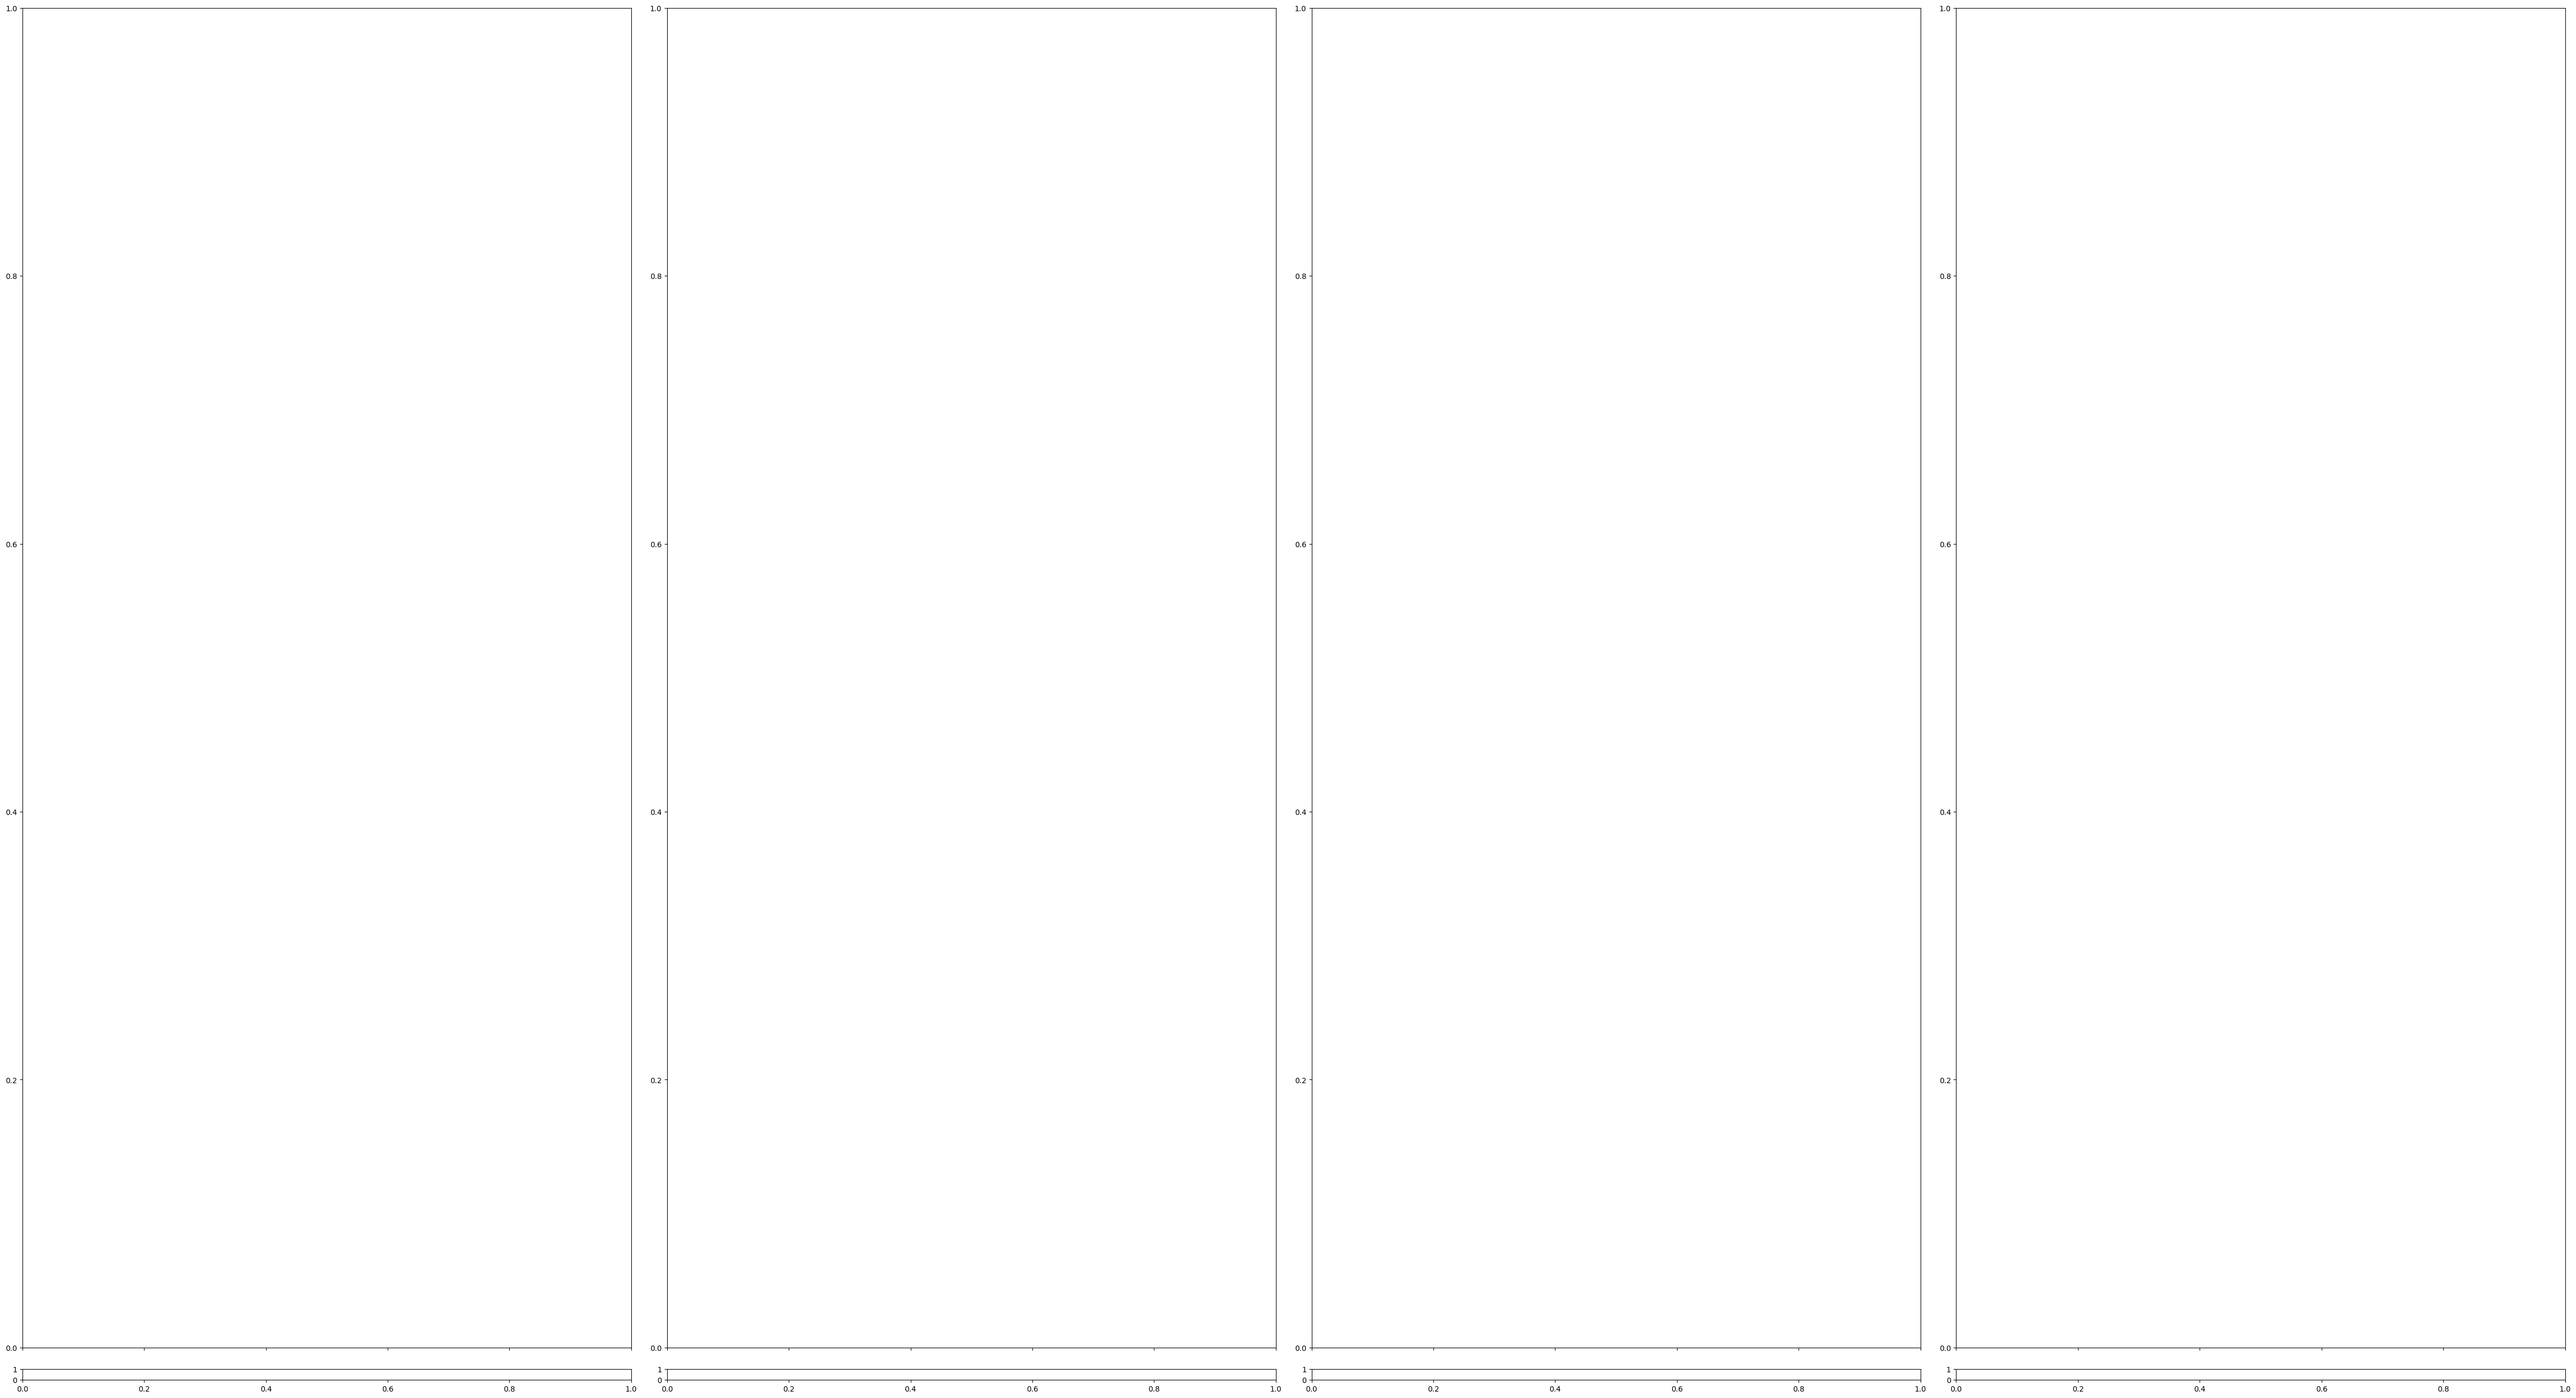

In [27]:
# Plot the timelines

num_requests = max([len(b.workflow.constrained_observation_requests) for b in world_with_brokers.brokers])
num_timelines = max([len(b.workflow.timelines) for b in world_with_brokers.brokers])

height_ratios = [num_requests]
height_ratios.extend([1,]*num_timelines)

fig, baxes = plt.subplots(
    num_timelines+1,
    len(world_with_brokers.brokers),
    sharex=True,
    height_ratios=height_ratios,
    figsize=(12*len(world_with_brokers.brokers), int(math.ceil(.2*num_requests+num_timelines))),
    layout="constrained"
    )

broker_axes = {}
if len(world_with_brokers.brokers)>1:
    for broker_ix, _broker in enumerate(world_with_brokers.brokers):
        broker_axes[_broker] = baxes[:, broker_ix]
else:
    broker_axes[world_with_brokers.brokers[0]] = baxes

## Start the workflows!

In [28]:
broker.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=False,
    plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=False,
    max_solver_time_s=300
    )

   [Scheduler] Scheduled request Initial observation on SKYSAT-C11 at Observation  at 2026-04-27 02:05:09.495000 by SKYSAT-C11 with InstrumentType.RGB. Look angle 72.38624668015322 | 54.22880089696621 az/dec deg, zenith angle 107.32784430785408 deg, range 497.7189153850987 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.0 on ICEYE-X64 at Observation  at 2026-04-27 05:42:02.982717 by ICEYE-X64 with InstrumentType.SAR. Look angle 115.47171277294122 | 75.18959634351457 az/dec deg, zenith angle 79.19860499936587 deg, range 635.6819601213705 km, duration 0:01:00
   [Scheduler] Could not schedule Follow-up search 1.1 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 1.2 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 1.3 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 1.4 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 1.5 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 1.6 (

In [29]:
other_broker.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=False,
    plot_axes=broker_axes[other_broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    plot_location_for_night_in_schedule=Gothenburg,
    save_schedule_plot=False,
    ) #, max_solver_time_s=10)

   [Scheduler] Scheduled request Initial observation on Ubotica CogniSat-6 HAMMER at Observation  at 2026-04-27 01:28:14.390022 by Ubotica CogniSat-6 HAMMER with InstrumentType.RGB. Look angle 72.69670333437416 | 66.54262499597483 az/dec deg, zenith angle 102.95860498584257 deg, range 466.19281576088224 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.0 on ICEYE-X6 at Observation  at 2026-04-27 04:44:38.678500 by ICEYE-X6 with InstrumentType.SAR. Look angle 98.40719314360639 | 65.50571732327143 az/dec deg, zenith angle 81.99004965657512 deg, range 617.2173798101801 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.1 on ICEYE-X63 at Observation  at 2026-04-27 04:59:46.517192 by ICEYE-X63 with InstrumentType.SAR. Look angle 100.3216989014962 | 49.64060639906954 az/dec deg, zenith angle 80.03043280656632 deg, range 783.2217570876718 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.2 on ICEYE-X64 at Observation  at 2026

In [30]:
broker_cities_asia.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=False,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
)

   [Scheduler] Scheduled request Huzhou on SKYSAT-C11 at Observation  at 2026-04-27 18:58:42.961952 by SKYSAT-C11 with InstrumentType.RGB. Look angle 311.8652331064904 | 80.27893300171861 az/dec deg, zenith angle 117.4246913321311 deg, range 411.0220505445915 km, duration 0:01:00
   [Scheduler] Scheduled request Morogoro on PELICAN-300A at Observation  at 2026-04-27 20:12:47.829888 by PELICAN-300A with InstrumentType.RGB. Look angle 283.60288268498107 | 73.25408208307547 az/dec deg, zenith angle 160.40389624831866 deg, range 467.98793988890543 km, duration 0:01:00
   [Scheduler] Scheduled request Rānchi on SKYSAT-C13 at Observation  at 2026-04-27 15:02:57.881468 by SKYSAT-C13 with InstrumentType.RGB. Look angle 262.0799200846986 | 35.099315186960695 az/dec deg, zenith angle 119.76363907657019 deg, range 516.2521971148578 km, duration 0:01:00
   [Scheduler] Scheduled request Jiangyin on PELICAN-300A at Observation  at 2026-04-27 14:08:52.548257 by PELICAN-300A with InstrumentType.RGB. L

In [31]:
broker_cities_america.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=False,
    # plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
)

   [Scheduler] Scheduled request Longueuil on PELICAN-3001 at Observation  at 2026-04-28 04:23:08.801336 by PELICAN-3001 with InstrumentType.RGB. Look angle 202.5071192865706 | 77.05255705041087 az/dec deg, zenith angle 119.97254377436832 deg, range 370.31671352527076 km, duration 0:01:00
   [Scheduler] Scheduled request Farmington Hills on SKYSAT-C13 at Observation  at 2026-04-28 01:43:04.736877 by SKYSAT-C13 with InstrumentType.RGB. Look angle 101.58335221312508 | 68.13625336675675 az/dec deg, zenith angle 102.99162996171223 deg, range 335.4122106066126 km, duration 0:01:00
   [Scheduler] Scheduled request Juazeiro on PELICAN-3001 at Observation  at 2026-04-28 02:37:44.784001 by PELICAN-3001 with InstrumentType.RGB. Look angle 63.05620615847447 | 61.86754114291361 az/dec deg, zenith angle 175.26848076980832 deg, range 406.14606673262523 km, duration 0:01:00
   [Scheduler] Scheduled request Peoria on PELICAN-3001 at Observation  at 2026-04-27 05:26:47.794507 by PELICAN-3001 with Instr

In [32]:
retcode = 1
while (retcode !=0):
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

Executing Event Obs, sat SKYSAT-C13 at 2026-04-27 01:11:25.344723
Executing Event ISL Downlink from sat SKYSAT-C13 at 2026-04-27 01:11:25.344723
Spacecraft SKYSAT-C13 has 1 data products to download
  Downlinked Observation  at 2026-04-27 01:11:25.344723 by SKYSAT-C13 with InstrumentType.RGB. Look angle 252.34312666234467 | 35.00209176209471 az/dec deg, zenith angle 138.42277131609063 deg, range 538.3391438933204 km, duration 0:01:00
 [Cities broker (America): ] data ready for request Request Buenos Aires, pass Pass start: 2026-04-27 01:07:04.013395, highest: 2026-04-27 01:11:27.567787, fall: 2026-04-27 01:15:47.741021, from Planet
 [Cities broker (America)] There are 0 dispatchable tasks
Executing Event Obs, sat Ubotica CogniSat-6 HAMMER at 2026-04-27 01:28:15.118241
Executing Event ISL Downlink from sat Ubotica CogniSat-6 HAMMER at 2026-04-27 01:28:15.118241
Spacecraft Ubotica CogniSat-6 HAMMER has 1 data products to download
  Downlinked Observation  at 2026-04-27 01:28:15.118241 by

In [33]:
save_prefix = "media/MSA_2ships_cities_v5"

In [34]:
# with open(f"{save_prefix}_chronicle.pkl",'wb') as file:
#     dill.dump(world_with_brokers.history, file)

In [35]:
retell_history(world_with_brokers)

Time: 2026-04-27 01:11:25.344723. Event: Event Obs, sat SKYSAT-C13 at 2026-04-27 01:11:25.344723
Observation: sat SKYSAT-C13 and opportunity Observation  at 2026-04-27 01:11:25.344723 by SKYSAT-C13 with InstrumentType.RGB. Look angle 252.34312666234467 | 35.00209176209471 az/dec deg, zenith angle 138.42277131609063 deg, range 538.3391438933204 km, duration 0:01:00
Time: 2026-04-27 01:11:25.344723. Event: Event ISL Downlink from sat SKYSAT-C13 at 2026-04-27 01:11:25.344723
Communication: station ISL to sat SKYSAT-C13 during pass ISL
Time: 2026-04-27 01:12:25.344723. Event: Event Unlock satellite after obs, sat SKYSAT-C13 at 2026-04-27 01:12:25.344723
Time: 2026-04-27 01:28:15.118241. Event: Event Obs, sat Ubotica CogniSat-6 HAMMER at 2026-04-27 01:28:15.118241
Observation: sat Ubotica CogniSat-6 HAMMER and opportunity Observation  at 2026-04-27 01:28:15.118241 by Ubotica CogniSat-6 HAMMER with InstrumentType.RGB. Look angle 70.95825634019103 | 66.55002665379486 az/dec deg, zenith angle 

13/14 (92.85714285714286%) of requests are in status ObservationStatus.DATA_RECEIVED
1/14 (7.142857142857142%) of requests are in status ObservationStatus.NO_OBSERVATION_OPPORTUNITIES
7/13 (53.84615384615385%) successful requests have a phenomenon detection

10/14 requests (71.43%) submitted to constellation ICEYE
9/13 successful requests (69.23%) submitted to constellation ICEYE
ICEYE submission success rate: 90.00%
1/14 requests (7.14%) submitted to constellation UBOTICA
1/13 successful requests (7.69%) submitted to constellation UBOTICA
UBOTICA submission success rate: 100.00%
2/14 requests (14.29%) submitted to constellation Umbra
2/13 successful requests (15.38%) submitted to constellation Umbra
Umbra submission success rate: 100.00%
1/14 requests (7.14%) submitted to constellation Planet
1/13 successful requests (7.69%) submitted to constellation Planet
Planet submission success rate: 100.00%
 13/14 (92.85714285714286%) unique requests have at least one successful observation
7/1

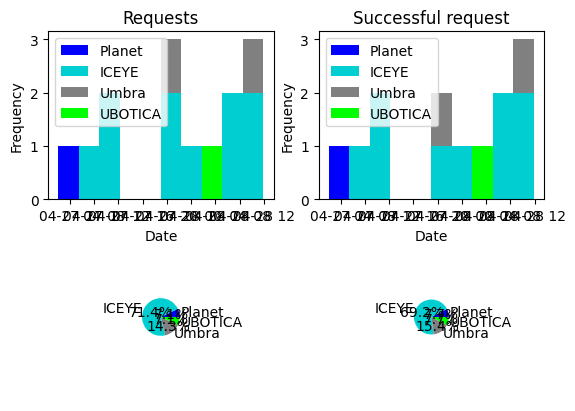

In [36]:
fig, stats_axes = plt.subplots(2,2)

stats_axes_linear = [stats_axes[0][0], stats_axes[1][0], stats_axes[0][1], stats_axes[1][1]]

plot_request_statistics(broker._requests, axes=stats_axes_linear, constellation_colors=constcolors)

request_statistics(broker._requests)

7/7 (100.0%) of requests are in status ObservationStatus.DATA_RECEIVED
5/7 (71.42857142857143%) successful requests have a phenomenon detection

5/7 requests (71.43%) submitted to constellation ICEYE
5/7 successful requests (71.43%) submitted to constellation ICEYE
ICEYE submission success rate: 100.00%
1/7 requests (14.29%) submitted to constellation Planet
1/7 successful requests (14.29%) submitted to constellation Planet
Planet submission success rate: 100.00%
1/7 requests (14.29%) submitted to constellation UBOTICA
1/7 successful requests (14.29%) submitted to constellation UBOTICA
UBOTICA submission success rate: 100.00%
 6/6 (100.0%) unique requests have at least one successful observation
4/6 (66.66666666666666%) of all successful unique requests have a phenomenon detection


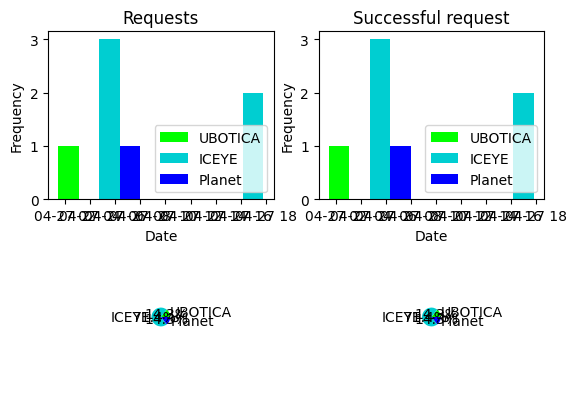

In [37]:
fig, stats_axes = plt.subplots(2,2)

stats_axes_linear = [stats_axes[0][0], stats_axes[1][0], stats_axes[0][1], stats_axes[1][1]]

plot_request_statistics(other_broker._requests, axes=stats_axes_linear, constellation_colors=constcolors)

request_statistics(other_broker._requests)

Failed to converge after 50 iterations, value is 1.10026388938517.
Failed to converge after 50 iterations, value is 1.1214935436033746.
Failed to converge after 50 iterations, value is 0.9647227012660118.
Failed to converge after 50 iterations, value is 0.8849238261690382.
Failed to converge after 50 iterations, value is 1.1501152147418134.
Failed to converge after 50 iterations, value is 2.195688279978578.


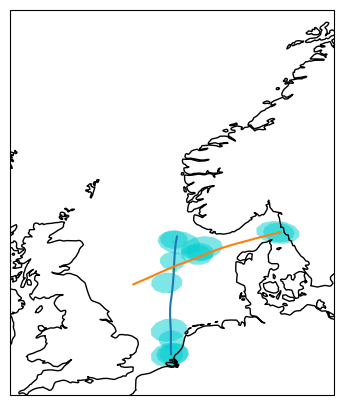

In [38]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.coastlines()
_plot_offset_deg = 10

mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            plot_time=False,
            plot_phenomena=False,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=False,
            plot_observation_target=False,
            plot_satellites=False
            )
        
ax.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")
ax.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")
plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.png".format(heading_variance, speed_variance),bbox_inches='tight')
plt.savefig("media/MSA2_observations_2ships_v2_sigmahdg_{}_sigmav_{}.pdf".format(heading_variance, speed_variance),bbox_inches='tight')


In [39]:
print("There were {} observations".format(len([_e for _e in world_with_brokers.history if (type(_e['event']) in [ObservationEvent,])])))

There were 70 observations


In [40]:

# def plot_event(
#         _chronicle: dict,
#         world: World,
#         ax=None,
#         satellite_colors: dict={},
#         satellite_markers: dict={},
#         constellation_colors: dict={},
#         plot_time: bool=True,
#         plot_phenomena: bool=True,
#         plot_phenomena_alpha: float=1.,
#         plot_ground_stations: bool=True,
#         plot_satellites: bool=True,
#         plot_satellite_tracks: bool=True,
#         plot_observation_gaze: bool=True,
#         plot_observation_target: bool=True,
#         plot_observation_footprint: bool=True,
#         plot_comm_gaze: bool=True,
#         plot_comm_station: bool=True,
#         ):
#     if ax is None:
#         figglobal = plt.figure(figsize=(10,5))
#         ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
#         ax.set_global()
#         ax.coastlines()

#     _time_to_plot_ground_track = dt.timedelta(seconds=3*60)
#     _dt_to_plot_ground_track = dt.timedelta(seconds=5)

#     time_steps_for_plotting = [_chronicle['time']- _dt_to_plot_ground_track*i for i in range(int(math.ceil(_time_to_plot_ground_track/_dt_to_plot_ground_track)))]

#     if plot_time:
#         ax.text(0,0,"{}".format(_chronicle['time']), transform=ax.transAxes)
    
#     constellation_palette = cmap['viridis'].resampled(len(world.constellations))

#     if plot_phenomena:
#         for phenomenon in _chronicle['phenomena']:
#             if (phenomenon.start_time<_chronicle['time'] and phenomenon.end_time>_chronicle['time']): 
#                 ax.plot(phenomenon.lon_deg, phenomenon.lat_deg, 'D', transform=ccrs.PlateCarree(), color='m', alpha=plot_phenomena_alpha)

#     for constellation_ix, constellation in enumerate(world.constellations):
#         constellation_color = constellation_colors.get(constellation.name, constellation_palette(constellation_ix/len(world.constellations)))
        

#         # Plot the ground stations
#         if plot_ground_stations:
#             for ground_station in constellation.ground_stations:
#                 ax.plot(float(ground_station.lon_deg), float(ground_station.lat_deg), '*', transform=ccrs.PlateCarree(), color=constellation_color)

#         # Plot the satellites
#         if plot_satellite_tracks:
#             for satellite in constellation.satellites:
#                 satellite_color = satellite_colors.get(satellite.name, constellation_color)
#                 _orbit = satellite.orbit
#                 _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
#                 # ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic(), color=constellation_color)
#                 for lla_ix in range(len(time_steps_for_plotting)-1):
#                     ax.plot([_llas[lla_ix+1][0], _llas[lla_ix][0]], [_llas[lla_ix+1][1], _llas[lla_ix][1]], transform=ccrs.Geodetic(), color=satellite_color, alpha = 1-(lla_ix+1)/len(_llas))

#     if type(_chronicle['event'])==ObservationEvent:
        
#         # Where are we looking - dashed line
#         if plot_observation_gaze:
#             ax.plot(
#                 [_chronicle['event'].opportunity.lon_deg, _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[0]],
#                 [_chronicle['event'].opportunity.lat_deg, _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[1]],
#                 ':k',
#                 transform=ccrs.Geodetic()
#             )

#         # The satellite location
#         satellite_color  = satellite_colors.get(_chronicle['event'].satellite.name, 'b')
#         satellite_marker = satellite_markers.get(_chronicle['event'].satellite.name, '.')
        
#         if plot_satellites:
#             ax.plot(
#                 _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[0],
#                 _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[1],
#                 satellite_marker,
#                 color=satellite_color,
#                 markersize=10,
#                 transform=ccrs.Geodetic()
#             )

#         # The center of the observation area
#         if plot_observation_target:
#             ax.plot(
#                 _chronicle['event'].opportunity.lon_deg,
#                 _chronicle['event'].opportunity.lat_deg,
#                 'Dr',
#                 # markersize=10,
#                 transform=ccrs.Geodetic()
#             )

#         # The sensor footprint
#         if plot_observation_footprint:
#             ground_footprint_llas = spacecraft_fov(
#                 _chronicle['time'],
#                 _chronicle['event'].satellite,
#                 _chronicle['event'].opportunity.instrument,
#                 _chronicle['event'].opportunity
#                 )
#             ground_footprint_poly = Polygon([(_lla[0], _lla[1]) for _lla in ground_footprint_llas])
#             ax.add_patch(patch_from_polygon(ground_footprint_poly, fc=satellite_color, ec='none', alpha=0.5, transform=ccrs.Geodetic()))

#     elif type(_chronicle['event'])==CommunicationEvent:
#         # The line from the GS to the satellite
#         if _chronicle['event'].station != "ISL":
#             if plot_comm_gaze:
#                 ax.plot(
#                     [_chronicle['event'].station.lon_deg, _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[0]],
#                     [_chronicle['event'].station.lat_deg, _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[1]],
#                     '-.k',
#                     transform=ccrs.Geodetic()
#                 )
#             # The station
#             if plot_comm_station:
#                 ax.plot(
#                     _chronicle['event'].station.lon_deg,
#                     _chronicle['event'].station.lat_deg,
#                     '*',
#                     markersize=10,
#                     transform=ccrs.Geodetic()
#                 )
#         # And the satellite
#         if plot_satellites:
#             satellite_color  = satellite_colors.get(_chronicle['event'].satellite.name, 'b')
#             satellite_marker = satellite_markers.get(_chronicle['event'].satellite.name, '.')
#             ax.plot(
#                 _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[0],
#                 _chronicle['event'].satellite.orbit.get_lonlatalt(_chronicle['time'])[1],
#                 satellite_marker,
#                 color=satellite_color,
#                 markersize=10,
#                 transform=ccrs.Geodetic()
#             )
#     return ax

In [41]:


def _plot_history(
        world: World,
        events_to_show: list,
        axes_extents: tuple=None,
        satellite_colors: dict={},
        satellite_markers: dict={},
        constellation_colors: dict={},
        plot_time: bool=True,
        plot_phenomena: bool=True,
        plot_phenomena_alpha: float=1.,
        plot_ground_stations: bool=True,
        plot_satellites: bool=True,
        plot_satellite_tracks: bool=True,
        plot_observation_gaze: bool=True,
        plot_observation_target: bool=True,
        plot_observation_footprint: bool=True,
        plot_comm_gaze: bool=True,
        plot_comm_station: bool=True,
        save_figure: bool=True,
        save_prefix: str="History_",
        use_sequential_index: bool=True,
        position_filter_parameters: dict={},
        ):
    artists = []
    plot_ix = -1
    for _chronicle_ix, _chronicle in enumerate(world.history):
        if type(_chronicle['event']) in events_to_show:
            figglobal = plt.figure(figsize=(20,10))
            ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
            if axes_extents is None:
                ax.set_global()
            
            else:
                ax.set_extent(axes_extents, crs=ccrs.PlateCarree())
            
            ax.coastlines()

            _ax = plot_event(
                _chronicle,
                world,
                ax=ax,
                satellite_colors=satellite_colors,
                satellite_markers=satellite_markers,
                constellation_colors=constellation_colors,
                plot_time=plot_time,
                plot_phenomena=plot_phenomena,
                plot_phenomena_alpha=plot_phenomena_alpha,
                plot_ground_stations=plot_ground_stations,
                plot_satellites=plot_satellites,
                plot_satellite_tracks=plot_satellite_tracks,
                plot_observation_gaze=plot_observation_gaze,
                plot_observation_target=plot_observation_target,
                plot_observation_footprint=plot_observation_footprint,
                plot_comm_gaze=plot_comm_gaze,
                plot_comm_station=plot_comm_station,
                )
            
            try:
                for broker_ix, broker in enumerate(_chronicle['states']['brokers']):
                    if broker.name in position_filter_parameters.keys():
                        # print(f"Plotting distribution for broker {broker.name}")
                        # A dict with (time, keys) pairs as generated by the broker
                        vehicle_hex_distribution = propagate_distribution_from_observations(
                            query_times=[_chronicle['time'],],
                            initial_pose=position_filter_parameters[broker.name]['initial_toi_pose'],
                            observation_requests=broker.workflow.constrained_observation_requests,
                            pose_propagator=lambda _previous_pose, _deltat: ship_propagator(
                                previous_pose=_previous_pose,
                                deltat=_deltat,
                                heading_variance=position_filter_parameters[broker.name]['heading_variance'],
                                speed_variance=position_filter_parameters[broker.name]['speed_variance'],
                                max_speed_if_unspecified_kph=position_filter_parameters[broker.name]['max_speed_if_unspecified_kph'],
                                ),
                            target_name=position_filter_parameters[broker.name]['target_name'],
                            h3_resolution=5, # Res 5: 9.85 km side. Res 6: 3.72 km side
                            # samples_propagation: int=200,
                            verbose=False,
                            plot_filter_distribution=False,
                            propagate_negative_samples=True,
                        )
                        # This will produce a distribution for _unfulfilled_ requests in the future. 
                        # It tells us where the broker will be looking next.
                        # Find the closest time step to the current time
                        if len(vehicle_hex_distribution.keys()):
                            closest_future_timestep = min(vehicle_hex_distribution.keys(), key=lambda t: t-_chronicle['time'] if t>_chronicle['time'] else dt.timedelta.max)
                            if closest_future_timestep<_chronicle['time']:
                                raise ValueError("The filter is looking in the past, that is very odd")
                        # Plot that
                        vehicle_hex_distribution[closest_future_timestep].plot(
                            ax=ax,
                            transform=ccrs.PlateCarree(), 
                            column='point_count',
                            cmap=position_filter_parameters[broker.name].get('color_scheme', 'Blues'),
                            alpha=.5,
                            # vmax=points_hex_tessellation['point_count'].max() + 1
                            )
                    # else:
                    #     print(f"Broker {broker.name} not in plotting keys")
            except ValueError as e:
                continue


            if use_sequential_index:
                plot_ix+=1
            else:
                plot_ix = _chronicle_ix
            if save_figure:
                plt.savefig("{}{:05d}.png".format(save_prefix, plot_ix), bbox_inches='tight')
            # artists.append(_ax)
                plt.close()
        

In [42]:
PLOT_HISTORY_TL = True



_plot_offset_deg = 8
axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Gothenburg.lat_deg)-_plot_offset_deg, float(Gothenburg.lat_deg)+_plot_offset_deg)

if PLOT_HISTORY_TL:

    _plot_history(
        world_with_brokers,
        events_to_show=[ObservationEvent,],
        axes_extents=axes_extents,
        plot_phenomena_alpha=.2,
        satellite_colors=satcolor,
        satellite_markers=satmarker,
        constellation_colors=constcolors,
        plot_observation_target=False,
        save_figure=True,
        save_prefix=save_prefix+"_history_",
        use_sequential_index=True,
        position_filter_parameters=filter_parameters_for_plotting,
        )

Failed to converge after 50 iterations, value is 1.10026388938517.
Failed to converge after 50 iterations, value is 1.1214935436033746.
Failed to converge after 50 iterations, value is 0.9647227012660118.
Failed to converge after 50 iterations, value is 0.8849238261690382.
Failed to converge after 50 iterations, value is 1.1501152147418134.
Failed to converge after 50 iterations, value is 2.195688279978578.


In [43]:
# figglobal = plt.figure(figsize=(10,5))
# ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# ax.coastlines()

# _plot_offset_deg = 8
# axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Gothenburg.lat_deg)-_plot_offset_deg, float(Gothenburg.lat_deg)+_plot_offset_deg)
# ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

# plot_event(
#     _chronicle,
#     world_with_brokers,
#     ax=ax,
#     satellite_colors=satcolor,
#     satellite_markers=satmarker,
#     constellation_colors=constcolors,
#     plot_time=_chronicle['time'],
#     plot_phenomena=True,
#     plot_ground_stations=False,
#     plot_satellites=True,
#     plot_satellite_tracks=True,
#     plot_observation_gaze=True,
#     plot_observation_target=False,
#     plot_observation_footprint=True,
#     plot_comm_gaze=True,
#     plot_comm_station=True,
#     )

In [44]:

def _plot_workflow_schedule(
        workflow_graph: nx.MultiDiGraph,
        timeline_graph: nx.MultiDiGraph=nx.MultiDiGraph(),
        axes=None,
        time: dt.datetime = None,
        feasibility_screener = lambda satellite, observation_pass: True,
        plot_title = "",
        show_night: bool=False,
        show_night_location: Location= Location(-118,34, 0),
        save_schedule_plot: bool=False,
        save_name: str = "Schedule.pdf",
        ):


    # num_requests = len(workflow_graph)
    # request_names = list(workflow_graph.nodes())

    request_group_names = list(dict.fromkeys([r.plotting_group for r in workflow_graph.nodes()]))
    num_request_groups = len(request_group_names)
    request_group_sizes = {g: len([r.plotting_group for r in workflow_graph.nodes() if r.plotting_group==g]) for g in request_group_names}

    # request_colors_list = cm.rainbow(np.linspace(0, 1, num_requests))
    # request_colors = {task: request_colors_list[task_ix] for task_ix, task in enumerate(request_names)}

    request_group_colors_list = cm.rainbow(np.linspace(0, 1, num_request_groups))
    request_group_colors = {group: request_group_colors_list[group_ix] for group_ix, group in enumerate(request_group_names)}

    num_timelines = len([n for n in timeline_graph.nodes() if type(n) == Timeline])


    if axes is None:
        height_ratios = [num_request_groups]
        height_ratios.extend([1,]*num_timelines)
        fig, axes = plt.subplots(num_timelines+1,1, sharex=True, height_ratios=height_ratios, figsize=(12, int(math.ceil(.2*num_request_groups+num_timelines))))
    else:
        if ((type(axes)==list) or (type(axes) == np.ndarray)):
            for ax in axes:
                ax.clear()
        else:
            axes.clear()


    if num_timelines>0:
        if ((type(axes)==list) or (type(axes) == np.ndarray)):
            ax_tasks = axes[0]
            if len(axes)>1:
                ax_timelines = axes[1:]
            else:
                ax_timelines = None
        else:
            ax_tasks = axes
            ax_timelines = None

    else:
        if ((type(axes)==list) or (type(axes) == np.ndarray)):
            ax_tasks = axes[0]
        else:
            ax_tasks = axes
        ax_timelines = None

    ax_tasks.set_title(plot_title)

    line_height = .8

    # Find max and min plotting time
    _all_requests_min_time = None 
    _all_requests_max_time = None
    for request in workflow_graph.nodes():
        
        if (request.scheduled and request.feasible):        # if 'observation_opportunities' in request.keys():
            for _sat, _opportunities in request.observation_opportunities.items():
                for _opportunity in _opportunities:
                    if _all_requests_min_time is None:
                        _all_requests_min_time = _opportunity.rise.time
                    else:
                        _all_requests_min_time = min(_all_requests_min_time, _opportunity.rise.time)
                    if _all_requests_max_time is None:
                        _all_requests_max_time = _opportunity.fall.time
                    else:
                        _all_requests_max_time = max(_all_requests_max_time, _opportunity.fall.time)

    # Annotete the plot with constraints: 
    ax_tasks.set_yticks(np.array(range(num_request_groups))+0.5, request_group_names)
    for request_ix, request in enumerate(workflow_graph.nodes()):
        # y_coordinate = request_ix
        y_coordinate = request_group_names.index(request.plotting_group)
        # Show the request intervals
        min_time = request.observation_request.min_time
        max_time = request.observation_request.max_time
        ax_tasks.add_patch(plt.Rectangle((min_time, y_coordinate), max_time-min_time, line_height, color=request_group_colors[request.plotting_group], alpha=.03/request_group_sizes[request.plotting_group]))
        # SHow the constraint intervals
        # For each constraint
        for parent_request in workflow_graph.predecessors(request):
            prequest_data = parent_request
            if (prequest_data.scheduled and prequest_data.feasible):
                parent_time = prequest_data.observation_opportunity.time
                inedges = workflow_graph.get_edge_data(parent_request, request)
                min_time = _all_requests_min_time
                max_time = _all_requests_max_time
                for constraint_key, constraint in inedges.items():
                    # print(constraint)
                    match constraint['constraint_class']:
                        case ConstraintClass.TEMPORAL:
                            match constraint['constraint_type']:
                                # These are constraints on the CURRENT node. So START_AFTER means the parent has to start before
                                case TemporalConstraintType.START_AFTER:
                                    min_time = max(min_time, parent_request.observation_opportunity.time)
                                case TemporalConstraintType.START_AFTER_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    min_time = max(min_time, parent_request.observation_opportunity.time+offset)
                                case TemporalConstraintType.START_BEFORE:
                                    max_time = min(max_time, parent_request.observation_opportunity.time)
                                case TemporalConstraintType.START_BEFORE_OFFSET:
                                    offset = constraint['parameters']['offset']
                                    max_time = min(max_time, parent_request.observation_opportunity.time+offset)
                        case ConstraintClass.SUCCESS:
                            # The current node needs to know if the parent succeeded. So we constrain the current node to start after the parent
                            min_time = max(min_time, parent_request.observation_opportunity.time)
                        case ConstraintClass.GEOMETRY:
                            min_time = max(min_time, parent_request.observation_opportunity.time)
                ax_tasks.add_patch(plt.Rectangle((min_time, y_coordinate), max_time-min_time, line_height, color=request_group_colors[parent_request.plotting_group], alpha=.1/request_group_sizes[request.plotting_group]))
        
        # Show where we actually ended up
        if (request.scheduled and request.feasible):
            if request.completed:
                _task_color = 'k'
                _task_width = 9
            elif request.dispatched:
                _task_color = 'm'
                _task_width = 6
            else:
                _task_color = request_group_colors[request.plotting_group]
                _task_width = 3
            # Plot the time where the request was scheduled.
            ax_tasks.vlines(request.observation_opportunity.time, y_coordinate, y_coordinate+line_height, color=_task_color, linewidth=_task_width)
        # Plot other times where it could have been scheduled.
        for _sat, _opportunities in request.observation_opportunities.items():
            for _opportunity in _opportunities:
                _pass_is_feasible = feasibility_screener(_sat, _opportunity)
                _min_time = _opportunity.rise.time
                _max_time = _opportunity.fall.time
                 
                pass_color = request_group_colors[request.plotting_group]
                pass_alpha = 0.1/request_group_sizes[request.plotting_group]
                if not _pass_is_feasible:
                    pass_color = 'red'
                    pass_alpha = 0.8/request_group_sizes[request.plotting_group]

                ax_tasks.add_patch(plt.Rectangle((_min_time, y_coordinate), _max_time-_min_time, line_height, color=pass_color, alpha=pass_alpha))

    if ax_timelines is not None:
        timeline_ix = 0
        for timeline in timeline_graph.nodes():
            if type(timeline) == Timeline:
                ax_timeline = ax_timelines[timeline_ix]
                _tl_times = []
                _tl_values = []
                for impact in timeline.impact_container:
                    _tl_times.append(impact.time)
                    _tl_values.append(timeline.get_value_at(impact.time))
                ax_timeline.plot(_tl_times, _tl_values, '-')
                timeline_ix += 1
                ax_timeline.set_ylabel(timeline.name,rotation=0, ha='right', va='center')
                ax_timeline.grid()

    if ax_timelines is not None:
        ax_timelines[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H'))
        ax_timelines[-1].tick_params(axis='x', labelrotation=45)
    else:
        ax_tasks.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H'))
        ax_tasks.tick_params(axis='x', labelrotation=45)
    # ax_tasks.set_xlim(_all_requests_min_time, _all_requests_max_time)

    # Show time
    if time is not None:
        ax_tasks.axvline(time, color='k', linewidth=1)

    if show_night:
        # List the days between all_requests_min_time and all_requests_max_time
        # Use sunrise to get rise, fall
        # If both are available
        # Plot a box from fall of day x to rise of day x+1
        # Start from min time
        # If the next object is sunrise, color black
        # until sunset
        #
        initial_date = _all_requests_min_time.date()
        final_date = _all_requests_max_time.date()
        all_dates = [initial_date+dt.timedelta(days=i) for i in range((final_date-initial_date).days+1)]
        
        _times = [(_all_requests_min_time, "I"), (_all_requests_max_time, "A")]
        for _date in all_dates:
            
            _sunrise_time = sun.sunrise(
                observer= Observer(latitude=show_night_location.lat_deg, longitude=show_night_location.lon_deg, elevation=show_night_location.alt_km/1e3),
                date=_date,
                tzinfo = dt.timezone.utc
            ).replace(tzinfo=None)
            _sunset_time = sun.sunset(
                observer= Observer(latitude=show_night_location.lat_deg, longitude=show_night_location.lon_deg, elevation=show_night_location.alt_km/1e3),
                date=_date,
                tzinfo = dt.timezone.utc
            ).replace(tzinfo=None)

            _times.append((_sunrise_time, "R"))
            _times.append((_sunset_time, "S"))
        _times.sort(key=lambda x: x[0])

        for _time_ix, _time in enumerate(_times[:-1]):
            #if the next time is a "R", then we are at night
            # Ignore anything before the min time
            if _time[0]<_all_requests_min_time:
                continue
            # If the next step is the max time, stop - that is a special case
            if _times[_time_ix+1][0]>=_all_requests_max_time:
                break 
            if _times[_time_ix+1][1] == "R":
                #if the next time is a "R", then we are at night
                # Plot black from _time to _times[_time_ix+1][0]
                ax_tasks.axvspan(xmin = _time[0], xmax=_times[_time_ix+1][0], color='gray', alpha=0.2)
        # At this point _time_ix is either len(_times)-2 or the location right before _all_requests_max_time
        
        # if the next time is the last one, then, was the time before the last a "S"? If so, we are at night
        if _times[_time_ix][1] == "S":
            # Plot black from _times[_time_ix][0] to _times[_time_ix+1][0]
            ax_tasks.axvspan(xmin = _times[_time_ix][0], xmax=_times[_time_ix+1][0], color='gray', alpha=0.2)

    if save_schedule_plot:
        plt.savefig(save_name, bbox_inches='tight')


In [45]:
def _plot_request_statistics(
        requests_pd,
        axes: plt.axes = None,
        broker_name: str="",
        bin_dt_width: dt.timedelta=dt.timedelta(hours=1),
        min_time: dt.datetime=None,
        max_time: dt.datetime=None,
        constellation_colors: dict={},
        MAX_RADIUS: float=50,
        save_plots: bool = True,
        save_prefix: str = "media/Statistics_",
        save_suffix: str = ".png",
        show_titles: bool = True,
        show_percentages: bool = True,
        ):

    if len(requests_pd) == 0:
        return
    if min_time is None:
        min_time = min(requests_pd['requested_pass'].apply(lambda x: x.highest.time if x is not None else None))
    if max_time is None:
        max_time = max(requests_pd['requested_pass'].apply(lambda x: x.highest.time if x is not None else None))

    histogram_bins = mdates.drange(min_time, max_time+bin_dt_width, bin_dt_width)

    sliced_requests_by_time_mask = requests_pd.apply(lambda row: ((row['requested_pass'].highest.time>=min_time) and (row['requested_pass'].highest.time<=max_time)), axis=1)

    sliced_requests_by_time = requests_pd[sliced_requests_by_time_mask]

    all_constellations = sliced_requests_by_time.requested_constellation.unique()
    # A cumulative chart with requests by constellation vs. time
    request_times_by_constellation = [
        sliced_requests_by_time[sliced_requests_by_time['requested_constellation']==_constellation]['requested_pass'].apply(lambda x: x.highest.time)
        for _constellation in all_constellations
    ]

    if axes is None:
        fig, axes = plt.subplots(2,2)

    if axes[0] is not None:
        axes[0].hist(
            request_times_by_constellation,
            bins=histogram_bins,
            stacked=True,
            label=[c.name for c in all_constellations],
            color=[constellation_colors.get(c.name, 'r') for c in all_constellations]
        )
        
        if show_titles:
            axes[0].set_title(f"Requests for broker {broker_name}")
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].tick_params(axis='x', labelrotation=45)
        # axes[0].tight_layout()

    pie_autopct_str = ''
    pie_labeldistance=None
    if show_percentages:
        pie_autopct_str = '%1.1f%%'
        pie_labeldistance=1.1


    if axes[1] is not None:
        num_requests = sum([len(rs) for rs in request_times_by_constellation])
        if num_requests>0:
            axes[1].pie(
                [len(rs) for rs in request_times_by_constellation],
                radius=sum([len(rs) for rs in request_times_by_constellation])/MAX_RADIUS,
                labels=[c.name for c in all_constellations],
                colors=[constellation_colors.get(c.name, 'r') for c in all_constellations],
                autopct=pie_autopct_str,
                labeldistance=pie_labeldistance,
                )
        else:
            axes[1].set_axis_off()

    # A cumulative chart with successful requests by constellation vs. time
    successful_request_times_by_constellation = [
        sliced_requests_by_time[(sliced_requests_by_time['requested_constellation']==_constellation) & (sliced_requests_by_time['status']==ObservationStatus.DATA_RECEIVED)]['requested_pass'].apply(lambda x: x.highest.time)
        for _constellation in all_constellations
    ]

    if axes[2] is not None:
        axes[2].hist(
            successful_request_times_by_constellation,
            bins=histogram_bins,
            stacked=True,
            label=[c.name for c in all_constellations],
            color=[constellation_colors.get(c.name, 'r') for c in all_constellations]
        )
        
        if show_titles:
            axes[2].set_title(f"Successful request for broker {broker_name}")
            axes[2].set_xlabel('Date')
            axes[2].set_ylabel('Frequency')
        axes[2].legend()
        axes[2].tick_params(axis='x', labelrotation=45)
        # axes[2].tight_layout()

    if axes[3] is not None:
        num_successful_requests = sum([len(rs) for rs in successful_request_times_by_constellation])
        if num_successful_requests>0:
            axes[3].pie(
                [len(rs) for rs in successful_request_times_by_constellation],
                radius=num_successful_requests/MAX_RADIUS,
                labels=[c.name for c in all_constellations],
                colors=[constellation_colors.get(c.name, 'r') for c in all_constellations],
                autopct=pie_autopct_str,
                labeldistance=pie_labeldistance,
                )
        else:
            axes[3].set_axis_off() 

    if save_plots:
        plt.savefig(save_prefix+save_suffix, bbox_inches='tight')

    

In [46]:

# def _propagate_distribution_from_observations(
#         query_times: list[dt.datetime],
#         initial_pose: Pose,
#         observation_requests: list[ConstrainedObservationRequest],
#         pose_propagator=None,
#         target_name: str="",
#         h3_resolution: int=5, # Res 5: 9.85 km side. Res 6: 3.72 km side
#         samples_propagation: int=200,
#         propagate_negative_samples: bool=True,
#         verbose: bool=False,
#         plot_filter_distribution: bool=True
#         ):

#     query_times.sort()
#     completed_requests = [r for r in observation_requests if r.completed == True]
#     # Walk from most recent backward to find the most recent time we saw the ship
#     completed_requests.sort(key=lambda x: x.observation_opportunity.time, reverse=True)
#     found_latest_request = False
#     completed_request_ix = 0
#     for completed_request in completed_requests:
#         if len(completed_request.data_product):
#             for ship_location_phenomenon in completed_request.data_product:
#                 # If the ship is the right one
#                 if ((len(target_name)==0) or (target_name in ship_location_phenomenon.name)):
#                     if verbose:
#                         print(f"Reinitializing the filter at {completed_request.observation_opportunity.time} (phenomenon {ship_location_phenomenon} matches string {target_name})")
#                     found_latest_request = True
#                     initial_pose = custom_ship_phenomenon_processor(
#                         observation=completed_request.observation_opportunity,
#                         spacecraft=completed_request.observation_opportunity.satellite,
#                         phenomenon=ship_location_phenomenon
#                         )
#                     break
#         if found_latest_request:
#             break
#         completed_request_ix += 1

#     ship_tracker = ShipTracker(initial_pose=initial_pose, pose_propagator=pose_propagator)

#     if propagate_negative_samples:
#         # # Walk from that point in the past to the present and remove particles incompatible with negative requests
#         if completed_request_ix>0: # If the positive observation was not the last request - recall these are reverse-ordered
#             for completed_request in reversed(completed_requests[:completed_request_ix-1]):
#                 # Recall we are going chronologically now, since we reversed
#                 # This is a completed request AFTER the latest successful one. So it is a negative result.
#                 _observation = completed_request.observation_opportunity
#                 if _observation.time > query_times[0]:
#                     raise ValueError("We have a successful observation in the past, that should never happen")
#                 if len(completed_request.data_product):
#                     for ship_location_phenomenon in completed_request.data_product:
#                         if ((len(target_name)==0) or (target_name in ship_location_phenomenon.name)):
#                             raise ValueError("Found successful observation {} after the supposedly last successful observation")
                
#                 ship_tracker.propagate_locations(_observation.time, samples=samples_propagation, max_dt=dt.timedelta(hours=3))
#                 _particles_out_of_fov = [p for p in ship_tracker.estimated_locations if (not is_lla_in_satellite_fov(observation=_observation, location=p))]
#                 ship_tracker.estimated_locations = _particles_out_of_fov
#                 ship_tracker.prune_locations(samples=samples_propagation)


#     # if plot_filter_distribution:
#     #     if plot_axis is None:
#     #         figglobal = plt.figure(figsize=(10,5))
#     #         plot_axis = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
#     #         plot_axis.coastlines()

#     #         fig_distribution, plot_distribution = plt.subplots(figsize=(10,5))
#     #         plot_distribution.set_title("Cumulative distribution across hexagons")

#     tessellations_by_time = {}

#     for urtime in query_times:
#         ship_tracker.propagate_locations(urtime, samples=samples_propagation, max_dt=dt.timedelta(hours=3))
#         ship_tracker.prune_locations(samples=samples_propagation) # Samples in propagate_location doesn't exactly do what we want...
        
#         # TESSELLATE WHAT YOU FOUND AND ADD REQUESTS ACCORDINGLY

#         points_gpd = gpd.GeoDataFrame(
#             {'lon': [pos.lon_deg for pos in ship_tracker.estimated_locations], 'lat': [pos.lat_deg for pos in ship_tracker.estimated_locations]},
#             geometry=gpd.points_from_xy([pos.lon_deg for pos in ship_tracker.estimated_locations], [pos.lat_deg for pos in ship_tracker.estimated_locations]),
#             crs="EPSG:4326"
#         )
#         # Res 5: 9.85 km side. Res 6: 3.72 km side

#         # if len(ship_tracker.estimated_locations) == 1:
#         h3_cell_ids = list(set([
#             h3.latlng_to_cell(est_loc.lat_deg, est_loc.lon_deg, h3_resolution)
#             for est_loc in ship_tracker.estimated_locations
#             ]))

#         points_hex_tessellation = gpd.GeoDataFrame(
#             {'h3_id': h3_cell_ids},
#             geometry = [h3_to_polygon(cell_id) for cell_id in h3_cell_ids],
#             crs="EPSG:4326",
#         )

#         # Counting points in each hex
#         joined_hexagons_and_points = gpd.sjoin(points_hex_tessellation, points_gpd, how="left", predicate="intersects")
#         points_hex_tessellation['point_count'] = joined_hexagons_and_points.groupby(joined_hexagons_and_points.index)['index_right'].count()

#         points_hex_tessellation.sort_values(by='point_count', ascending=False, inplace=True)

#         tessellations_by_time[urtime] = points_hex_tessellation

#         # if plot_filter_distribution:
#         #     total_points = len(ship_tracker.estimated_locations)
#         #     cumulative_points = 0
#         #     point_distribution = []
#         #     for index, row in points_hex_tessellation.iterrows():
#         #         points = row['point_count']
#         #         cumulative_points+=points
#         #         point_distribution.append(cumulative_points/total_points)
#         #     # print("Done, plotting")
#         #     points_gpd.plot(ax=plot_axis, transform=ccrs.Geodetic(), markersize=3, label=urtime,alpha=.1)
#         #     points_hex_tessellation.plot(
#         #         ax=plot_axis,
#         #         transform=ccrs.PlateCarree(), 
#         #         column='point_count',
#         #         cmap='Blues',
#         #         alpha=.9,
#         #         # vmax=points_hex_tessellation['point_count'].max() + 1
#         #         )
            
#         #     plot_distribution.plot(list(range(len(point_distribution))), point_distribution, label=urtime)

#     return tessellations_by_time

In [ ]:
def plot_chronicle(
        chronicle: dict,
        world: World,
        satellite_colors: dict={},
        satellite_markers: dict={},
        constellation_colors: dict={},
        local_axes_extent: tuple=None,
        plot_time: bool=True,
        plot_phenomena: bool=True,
        plot_phenomena_alpha: float=1.0,
        plot_ground_stations: bool=True,
        plot_satellites: bool=True,
        plot_satellite_tracks: bool=True,
        plot_observation_gaze: bool=True,
        plot_observation_target: bool=True,
        plot_observation_footprint: bool=True,
        plot_comm_gaze: bool=True,
        plot_comm_station: bool=True,
        show_night: bool=False,
        show_night_location: Location= Location(-118,34, 0),
        time_limits: list=[None, None],
        position_filter_parameters: dict={},
        ):

    num_brokers = len(chronicle['states']['brokers'])
    top_mosaic_row = ["Event_global"]
    if local_axes_extent:
        top_mosaic_row = ["Event_local"]
    # mid_mosaic_row = ["Event_global"]
    # mid_mosaic_row.extend([f"Broker {i} timeline" for i in range(num_brokers)])
    bottom_mosaic_row = ["Event_global"]
    for i in range(num_brokers):
        top_mosaic_row.extend([f"Broker {i} events", f"Broker {i} events"])
        # mid_mosaic_row.extend([f"Broker {i} timeline", f"Broker {i} timeline"])
        bottom_mosaic_row.extend([f"Broker {i} stats A", f"Broker {i} stats B" ])

    mosaic_rows = [top_mosaic_row, bottom_mosaic_row]

    width_ratios = [5]

    width_ratios.extend([1.3, 0.7]*num_brokers)
    height_ratios = [2,1]

    per_subplot_kw={
        "Event_global": {"projection": ccrs.Robinson()},
    }
    if local_axes_extent:
        per_subplot_kw["Event_local"] = {"projection": ccrs.Robinson()}

    fig, axes = plt.subplot_mosaic(
        mosaic_rows,
        per_subplot_kw=per_subplot_kw,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        figsize=[14+6*num_brokers,10]
        )
    
    # Plot the event: satellites overhead, observations
    axes['Event_global'].set_global()
    axes['Event_global'].coastlines()

    if local_axes_extent:
        axes['Event_local'].set_extent(local_axes_extent, crs=ccrs.PlateCarree())
        axes['Event_local'].coastlines()

    plot_time_global = plot_time
    plot_phenomena_global = plot_phenomena


    # Turn off some things for redundancy
    if local_axes_extent:
        plot_time_global = False
        plot_phenomena_global = False
    
    plot_event(
        _chronicle=chronicle,
        world=world,
        ax=axes['Event_global'],
        satellite_colors=satellite_colors,
        satellite_markers=satellite_markers,
        constellation_colors=constellation_colors,
        plot_time=plot_time_global,
        plot_phenomena=plot_phenomena_global,
        plot_phenomena_alpha=plot_phenomena_alpha,
        plot_satellite_tracks=plot_satellite_tracks,
        plot_ground_stations=plot_ground_stations,
        plot_observation_gaze=plot_observation_gaze,
        plot_observation_target=plot_observation_target,
        plot_satellites=plot_satellites,
        plot_observation_footprint=plot_observation_footprint,
        plot_comm_gaze=plot_comm_gaze,
        plot_comm_station=plot_comm_station,
        )
    
    if local_axes_extent:
        plot_event(
            _chronicle=chronicle,
            world=world,
            ax=axes['Event_local'],
            satellite_colors=satellite_colors,
            satellite_markers=satellite_markers,
            constellation_colors=constellation_colors,
            plot_time=plot_time,
            plot_phenomena=plot_phenomena,
            plot_phenomena_alpha=plot_phenomena_alpha,
            plot_satellite_tracks=plot_satellite_tracks,
            plot_ground_stations=plot_ground_stations,
            plot_observation_gaze=plot_observation_gaze,
            plot_observation_target=plot_observation_target,
            plot_satellites=plot_satellites,
            plot_observation_footprint=plot_observation_footprint,
            plot_comm_gaze=plot_comm_gaze,
            plot_comm_station=plot_comm_station,
            )
        # Plot the filter distribution of where it thinks the ship may be
        try:
            for broker_ix, broker in enumerate(chronicle['states']['brokers']):
                if broker.name in position_filter_parameters.keys():
                    # print(f"Plotting distribution for broker {broker.name}")
                    # A dict with (time, keys) pairs as generated by the broker
                    vehicle_hex_distribution = propagate_distribution_from_observations(
                        query_times=[chronicle['time'],],
                        initial_pose=position_filter_parameters[broker.name]['initial_toi_pose'],
                        observation_requests=broker.workflow.constrained_observation_requests,
                        pose_propagator=lambda _previous_pose, _deltat: ship_propagator(
                            previous_pose=_previous_pose,
                            deltat=_deltat,
                            heading_variance=position_filter_parameters[broker.name]['heading_variance'],
                            speed_variance=position_filter_parameters[broker.name]['speed_variance'],
                            max_speed_if_unspecified_kph=position_filter_parameters[broker.name]['max_speed_if_unspecified_kph'],
                            ),
                        target_name=position_filter_parameters[broker.name]['target_name'],
                        h3_resolution=5, # Res 5: 9.85 km side. Res 6: 3.72 km side
                        # samples_propagation: int=200,
                        verbose=False,
                        plot_filter_distribution=False,
                        propagate_negative_samples=True,
                    )
                    # Plot that
                    vehicle_hex_distribution[chronicle['time']].plot(
                        ax=axes['Event_local'],
                        transform=ccrs.PlateCarree(), 
                        column='point_count',
                        cmap=position_filter_parameters[broker.name].get('color_scheme', 'Blues'),
                        alpha=.5,
                        # vmax=points_hex_tessellation['point_count'].max() + 1
                        )
                # else:
                #     print(f"Broker {broker.name} not in plotting keys")
        except ValueError as e:
            print(e)
    
    # For each broker, plot the schedule, at the current time
    for broker_ix, broker in enumerate(chronicle['states']['brokers']):

        _plot_workflow_schedule(
            workflow_graph=broker._workflow_graph,
            timeline_graph=broker._timeline_graph,
            # axes=[axes[f"Broker {broker_ix} events"], axes[f"Broker {broker_ix} timeline"]],
            axes=axes[f"Broker {broker_ix} events"],
            time=chronicle['time'],
            feasibility_screener=broker._screen_pass_for_feasibility,
            plot_title=f"{broker.name} (epoch {broker._workflow_schedule_epoch})",
            show_night=show_night,
            show_night_location=show_night_location,
            save_schedule_plot=False,
            # save_name = "Schedule_e{}_{}.pdf".format(self._workflow_schedule_epoch, self.world.time)
            )
        if (len(time_limits)>=2 and (time_limits[0] is not None) and (time_limits[1] is not None)):
            axes[f"Broker {broker_ix} events"].set_xlim(time_limits[0],time_limits[1])
        # Plot the statistics, histograms
        # dump_fig, dump_axes = plt.subplots(3,1)
        stats_axes = [None, None, axes[f"Broker {broker_ix} stats A"], axes[f"Broker {broker_ix} stats B"]]
        if (len(time_limits)>=2 and (time_limits[0] is not None) and (time_limits[1] is not None)):
            axes[f"Broker {broker_ix} stats A"].set_xlim(time_limits[0],time_limits[1])
        _plot_request_statistics(
            broker._requests,
            axes=stats_axes,
            constellation_colors=constellation_colors,
            save_plots=False,
            show_titles=False,
            show_percentages=False,
            )

    # Plot the tracker distributions

    # fig.autofmt_xdate()

In [ ]:
PLOT_HISTORY_CHRONICLE = True
times = [c['time'] for c in world_with_brokers.history]

_plot_offset_deg = 8
local_axes_extent = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Gothenburg.lat_deg)-_plot_offset_deg, float(Gothenburg.lat_deg)+_plot_offset_deg)

if PLOT_HISTORY_CHRONICLE:
    for chronicle_ix, chronicle in enumerate(world_with_brokers.history):
        plot_chronicle(
            chronicle=chronicle,
            world=world_with_brokers,
            local_axes_extent=local_axes_extent,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolors,
            show_night=False,
            plot_time=True,
            plot_phenomena=True,
            plot_satellite_tracks=True,
            plot_ground_stations=False,
            plot_observation_gaze=True,
            plot_observation_target=False,
            plot_satellites=False,
            time_limits = [min(times), max(times)],
            position_filter_parameters=filter_parameters_for_plotting,
            )

        plt.savefig("{}{:05d}.png".format(save_prefix+"_chronicles_", chronicle_ix), bbox_inches='tight')
        plt.close()


/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_982/196876876.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_982/196876876.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_982/196876876.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_982/196876876.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an undersco